# End-to-end collaborative filtering pipeline using the Surprise library: EDA, SVD/NMF/KNN models, evaluation (RMSE/MAE/Precision@K), and top-N recommendations on the MovieLens 100K dataset.

## Matrix Factorization using SVD/ALS

**Objective:** Build a recommendation system that predicts user preferences and suggests personalized items using Collaborative Filtering. This technique powers major platforms like Netflix, Amazon, and Spotify to enhance user engagement and retention.

**Dataset:** MovieLens 100K - A classic dataset with user-movie ratings

**Author:** [Mayur Ingle](https://www.linkedin.com/in/mayuringle/)  


---

## Table of Contents
1. [Introduction & Setup](#introduction)
2. [Data Loading & Exploration](#data-loading)
3. [Data Preprocessing](#preprocessing)
4. [Matrix Factorization Models (SVD/ALS)](#models)
5. [Model Evaluation](#evaluation)
6. [Generate Recommendations](#recommendations)
7. [Insights & Future Work](#insights)

## 1. Introduction & Setup <a id='introduction'></a>

### What is Collaborative Filtering?

**Collaborative Filtering** is a technique that predicts user preferences based on the collective behavior of many users. The key assumption is that users who agreed in the past will agree in the future.

### Matrix Factorization Approach

We represent user-item interactions as a matrix **R** where:
- Rows represent users
- Columns represent items
- Values represent ratings

Matrix factorization decomposes R into two lower-dimensional matrices:
```
R ≈ P × Q^T
```
Where:
- **P**: User latent feature matrix (users × k factors)
- **Q**: Item latent feature matrix (items × k factors)
- **k**: Number of latent factors (hyperparameter)

### Algorithms We'll Use
1. **SVD (Singular Value Decomposition)**: Factorizes the rating matrix into user and item latent vectors
2. **ALS (Alternating Least Squares)**: Iteratively optimizes user and item factors

Let's import the necessary libraries!

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Surprise library for collaborative filtering
from surprise import SVD, NMF, KNNBasic, KNNWithMeans
from surprise import Dataset, Reader
from surprise import accuracy
from surprise.model_selection import train_test_split, cross_validate, GridSearchCV

# Sklearn utilities
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ All libraries imported successfully!")

ModuleNotFoundError: No module named 'pandas'

## 2. Data Loading & Exploration <a id='data-loading'></a>

We'll use the **MovieLens 100K** dataset, which contains:
- 100,000 ratings
- 943 users
- 1,682 movies
- Ratings on a scale of 1-5

The Surprise library provides easy access to this dataset.

In [ ]:
# Install Surprise if needed
!pip install -q scikit-surprise

# Imports
from surprise import Dataset, Reader
import pandas as pd
from surprise.model_selection import train_test_split

# Update this to the exact Kaggle path for your uploaded dataset
file_path = 'C:\Users\Med\Documents\movies lens recmendation\ml-100k\u.data'

# Option A: load directly from the u.data file
reader = Reader(line_format='user item rating timestamp', sep='\t')
data = Dataset.load_from_file(file_path, reader=reader)

# or Option B: load with pandas then convert to Surprise Dataset
cols = ['user_id', 'item_id', 'rating', 'timestamp']
ratings = pd.read_csv(file_path, sep='\t', names=cols, engine='python')
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['user_id', 'item_id', 'rating']], reader)

# example split
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)
print("Loaded ratings:", ratings.shape)

# Convert to pandas DataFrame for easier exploration
df = pd.DataFrame(data.raw_ratings, columns=['user_id', 'item_id', 'rating', 'timestamp'])

print(f"\n📊 Dataset Shape: {df.shape}")
print(f"   - Total Ratings: {len(df):,}")
print(f"   - Unique Users: {df['user_id'].nunique():,}")
print(f"   - Unique Items: {df['item_id'].nunique():,}")

Loaded ratings: (100000, 4)

📊 Dataset Shape: (100000, 4)
   - Total Ratings: 100,000
   - Unique Users: 943
   - Unique Items: 1,682


In [3]:
# Display first few rows
print("\n🔍 First 10 Rows:")
df.head(10)


🔍 First 10 Rows:


,user_id,item_id,rating,timestamp
0,196,242,3.0,None
1,186,302,3.0,None
2,22,377,1.0,None
3,244,51,2.0,None
4,166,346,1.0,None
5,298,474,4.0,None
6,115,265,2.0,None
7,253,465,5.0,None
8,305,451,3.0,None
9,6,86,3.0,None


In [4]:
# Basic statistics
print("\n📈 Dataset Statistics:")
df.describe()


📈 Dataset Statistics:


,user_id,item_id,rating
count,100000.00000,100000.000000,100000.000000
mean,462.48475,425.530130,3.529860
std,266.61442,330.798356,1.125674
min,1.00000,1.000000,1.000000
25%,254.00000,175.000000,3.000000
50%,447.00000,322.000000,4.000000
75%,682.00000,631.000000,4.000000
max,943.00000,1682.000000,5.000000


In [5]:
# Check for missing values
print("\n🔍 Missing Values:")
print(df.isnull().sum())
print("\n✅ No missing values found!" if df.isnull().sum().sum() == 0 else "⚠️ Missing values detected!")


🔍 Missing Values:
user_id           0
item_id           0
rating            0
timestamp    100000
dtype: int64
⚠️ Missing values detected!


### 2.1 Exploratory Data Analysis (EDA)

Let's visualize the distribution of ratings and user/item activity.

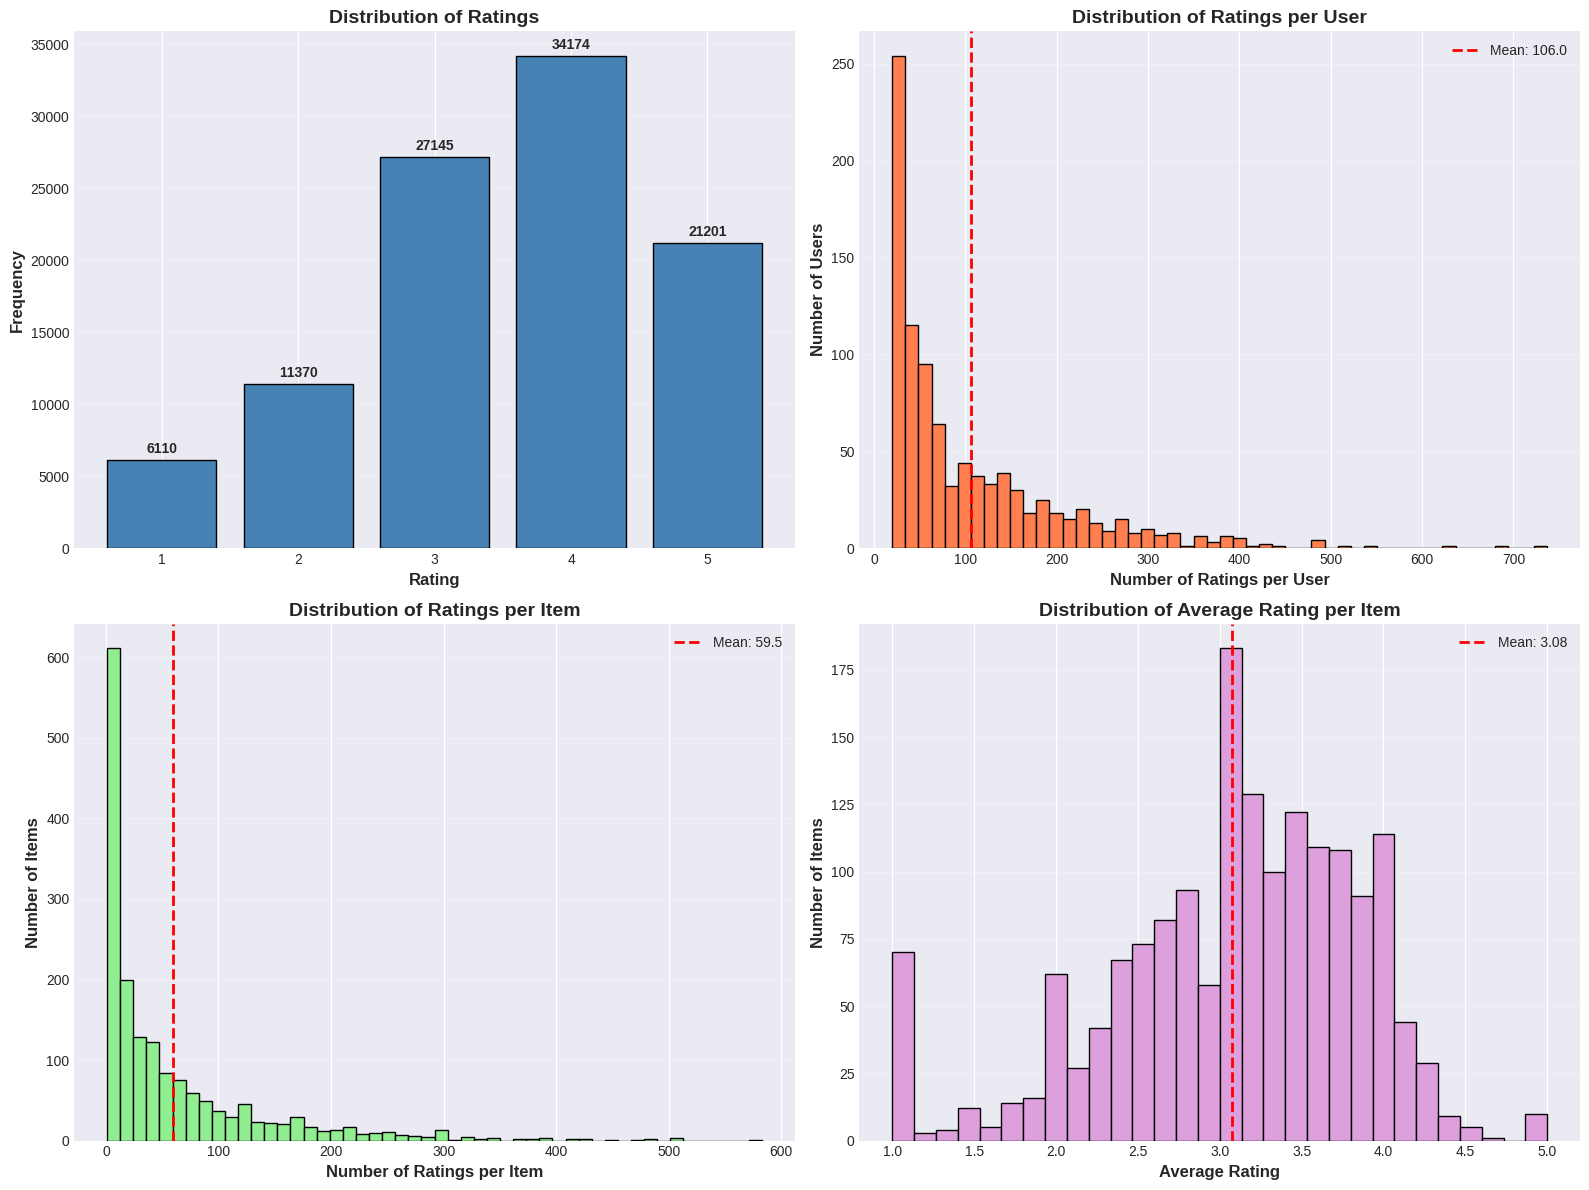


📊 Key Statistics:
   - Average rating: 3.53
   - Median rating: 4.00
   - Most common rating: 4.0
   - Average ratings per user: 106.0
   - Average ratings per item: 59.5


In [6]:
# Rating distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Rating distribution
ax1 = axes[0, 0]
rating_counts = df['rating'].value_counts().sort_index()
ax1.bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')
ax1.set_xlabel('Rating', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Ratings', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(rating_counts.values):
    ax1.text(rating_counts.index[i], v + 500, str(v), ha='center', fontweight='bold')

# 2. Ratings per user
ax2 = axes[0, 1]
user_rating_counts = df.groupby('user_id').size()
ax2.hist(user_rating_counts, bins=50, color='coral', edgecolor='black')
ax2.set_xlabel('Number of Ratings per User', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Users', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of Ratings per User', fontsize=14, fontweight='bold')
ax2.axvline(user_rating_counts.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {user_rating_counts.mean():.1f}')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Ratings per item
ax3 = axes[1, 0]
item_rating_counts = df.groupby('item_id').size()
ax3.hist(item_rating_counts, bins=50, color='lightgreen', edgecolor='black')
ax3.set_xlabel('Number of Ratings per Item', fontsize=12, fontweight='bold')
ax3.set_ylabel('Number of Items', fontsize=12, fontweight='bold')
ax3.set_title('Distribution of Ratings per Item', fontsize=14, fontweight='bold')
ax3.axvline(item_rating_counts.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {item_rating_counts.mean():.1f}')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Average rating per item
ax4 = axes[1, 1]
avg_item_rating = df.groupby('item_id')['rating'].mean()
ax4.hist(avg_item_rating, bins=30, color='plum', edgecolor='black')
ax4.set_xlabel('Average Rating', fontsize=12, fontweight='bold')
ax4.set_ylabel('Number of Items', fontsize=12, fontweight='bold')
ax4.set_title('Distribution of Average Rating per Item', fontsize=14, fontweight='bold')
ax4.axvline(avg_item_rating.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_item_rating.mean():.2f}')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Key Statistics:")
print(f"   - Average rating: {df['rating'].mean():.2f}")
print(f"   - Median rating: {df['rating'].median():.2f}")
print(f"   - Most common rating: {df['rating'].mode()[0]}")
print(f"   - Average ratings per user: {user_rating_counts.mean():.1f}")
print(f"   - Average ratings per item: {item_rating_counts.mean():.1f}")


🧮 Sparsity Analysis:
   - Total possible ratings: 1,586,126
   - Actual ratings: 100,000
   - Sparsity: 93.70%
   - Density: 6.30%


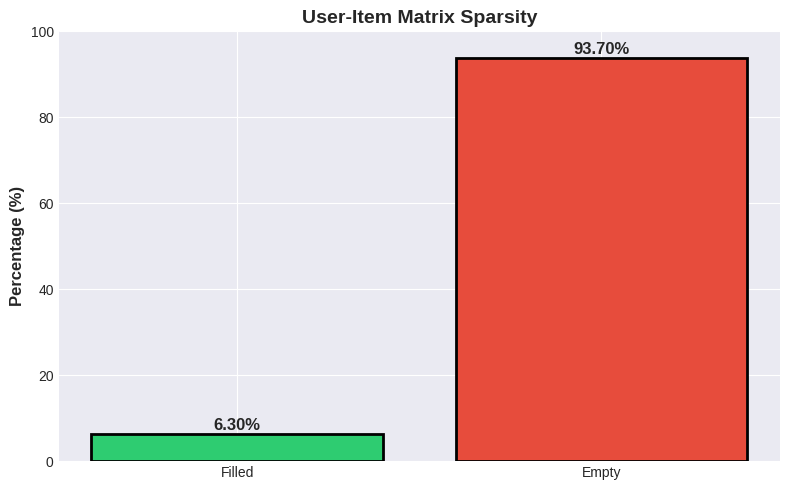

In [7]:
# Sparsity analysis
n_users = df['user_id'].nunique()
n_items = df['item_id'].nunique()
n_ratings = len(df)
possible_ratings = n_users * n_items
sparsity = 1 - (n_ratings / possible_ratings)

print("\n🧮 Sparsity Analysis:")
print(f"   - Total possible ratings: {possible_ratings:,}")
print(f"   - Actual ratings: {n_ratings:,}")
print(f"   - Sparsity: {sparsity*100:.2f}%")
print(f"   - Density: {(1-sparsity)*100:.2f}%")

# Visualize sparsity
fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Filled', 'Empty']
values = [(1-sparsity)*100, sparsity*100]
colors = ['#2ecc71', '#e74c3c']
ax.bar(categories, values, color=colors, edgecolor='black', linewidth=2)
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('User-Item Matrix Sparsity', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
for i, v in enumerate(values):
    ax.text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


🔥 User-Item Interaction Heatmap (Sample: 50x50)


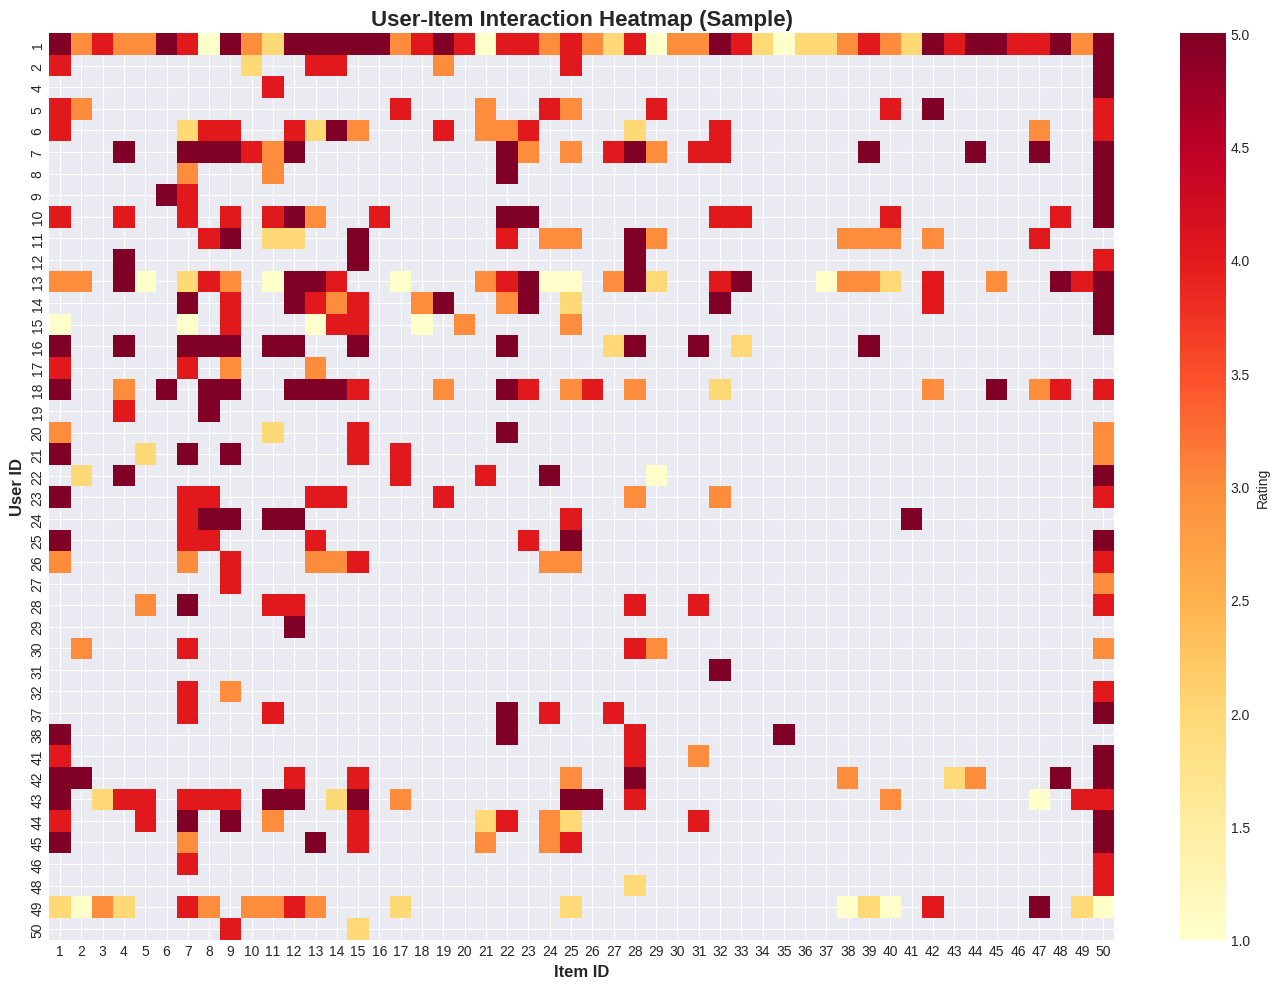


⚠️ White spaces indicate missing ratings (user hasn't rated that item)


In [8]:
# Sample user-item interaction heatmap (first 50 users and 50 items)
print("\n🔥 User-Item Interaction Heatmap (Sample: 50x50)")

# Create pivot table for first 50 users and items
sample_users = sorted(df['user_id'].unique())[:50]
sample_items = sorted(df['item_id'].unique())[:50]
sample_df = df[(df['user_id'].isin(sample_users)) & (df['item_id'].isin(sample_items))]
pivot_sample = sample_df.pivot_table(index='user_id', columns='item_id', values='rating')

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_sample, cmap='YlOrRd', cbar_kws={'label': 'Rating'}, 
            linewidths=0, square=False)
plt.title('User-Item Interaction Heatmap (Sample)', fontsize=16, fontweight='bold')
plt.xlabel('Item ID', fontsize=12, fontweight='bold')
plt.ylabel('User ID', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n⚠️ White spaces indicate missing ratings (user hasn't rated that item)")

## 3. Data Preprocessing <a id='preprocessing'></a>

We'll split the data into training and test sets to evaluate our models.

In [9]:
# Split data into train and test sets (80-20 split)
print("\n✂️ Splitting data into train and test sets...")
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print(f"   - Training set size: {trainset.n_ratings:,} ratings")
print(f"   - Test set size: {len(testset):,} ratings")
print(f"   - Train-Test ratio: {trainset.n_ratings/len(testset):.2f}:1")
print("\n✅ Data split complete!")


✂️ Splitting data into train and test sets...
   - Training set size: 80,000 ratings
   - Test set size: 20,000 ratings
   - Train-Test ratio: 4.00:1

✅ Data split complete!


## 4. Matrix Factorization Models (SVD/ALS) <a id='models'></a>

We'll implement and compare multiple collaborative filtering algorithms:
1. **SVD**: Singular Value Decomposition
2. **NMF**: Non-negative Matrix Factorization (similar to ALS)
3. **KNN**: K-Nearest Neighbors baseline

### 4.1 SVD (Singular Value Decomposition)

In [10]:
# Train SVD model
print("\n🤖 Training SVD Model...")
print("   Parameters: n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02")

svd_model = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
svd_model.fit(trainset)

print("✅ SVD model trained successfully!")


🤖 Training SVD Model...
   Parameters: n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02
✅ SVD model trained successfully!


In [11]:
# Test SVD model
print("\n📊 Evaluating SVD Model on Test Set...")
svd_predictions = svd_model.test(testset)

svd_rmse = accuracy.rmse(svd_predictions, verbose=True)
svd_mae = accuracy.mae(svd_predictions, verbose=True)

print(f"\n📈 SVD Results:")
print(f"   - RMSE: {svd_rmse:.4f}")
print(f"   - MAE: {svd_mae:.4f}")


📊 Evaluating SVD Model on Test Set...
RMSE: 0.9352
MAE:  0.7375

📈 SVD Results:
   - RMSE: 0.9352
   - MAE: 0.7375


### 4.2 NMF (Non-negative Matrix Factorization)

NMF is similar to ALS but ensures all factors are non-negative, which can lead to more interpretable features.

In [12]:
# Train NMF model
print("\n🤖 Training NMF Model (ALS-like)...")
print("   Parameters: n_factors=100, n_epochs=50")

nmf_model = NMF(n_factors=100, n_epochs=50, random_state=42)
nmf_model.fit(trainset)

print("✅ NMF model trained successfully!")


🤖 Training NMF Model (ALS-like)...
   Parameters: n_factors=100, n_epochs=50
✅ NMF model trained successfully!


In [13]:
# Test NMF model
print("\n📊 Evaluating NMF Model on Test Set...")
nmf_predictions = nmf_model.test(testset)

nmf_rmse = accuracy.rmse(nmf_predictions, verbose=True)
nmf_mae = accuracy.mae(nmf_predictions, verbose=True)

print(f"\n📈 NMF Results:")
print(f"   - RMSE: {nmf_rmse:.4f}")
print(f"   - MAE: {nmf_mae:.4f}")


📊 Evaluating NMF Model on Test Set...
RMSE: 1.1017
MAE:  0.8394

📈 NMF Results:
   - RMSE: 1.1017
   - MAE: 0.8394


### 4.3 KNN Baseline (for comparison)

In [14]:
# Train KNN model
print("\n🤖 Training KNN Model...")
print("   Parameters: k=40, similarity=cosine")

knn_model = KNNWithMeans(k=40, sim_options={'name': 'cosine', 'user_based': True}, random_state=42)
knn_model.fit(trainset)

print("✅ KNN model trained successfully!")


🤖 Training KNN Model...
   Parameters: k=40, similarity=cosine
Computing the cosine similarity matrix...
Done computing similarity matrix.
✅ KNN model trained successfully!


In [15]:
# Test KNN model
print("\n📊 Evaluating KNN Model on Test Set...")
knn_predictions = knn_model.test(testset)

knn_rmse = accuracy.rmse(knn_predictions, verbose=True)
knn_mae = accuracy.mae(knn_predictions, verbose=True)

print(f"\n�� KNN Results:")
print(f"   - RMSE: {knn_rmse:.4f}")
print(f"   - MAE: {knn_mae:.4f}")


📊 Evaluating KNN Model on Test Set...
RMSE: 0.9538
MAE:  0.7526

�� KNN Results:
   - RMSE: 0.9538
   - MAE: 0.7526


## 5. Model Evaluation <a id='evaluation'></a>

Let's compare all models and visualize their performance.

In [16]:
# Model comparison
results_df = pd.DataFrame({
    'Model': ['SVD', 'NMF (ALS-like)', 'KNN'],
    'RMSE': [svd_rmse, nmf_rmse, knn_rmse],
    'MAE': [svd_mae, nmf_mae, knn_mae]
})

print("\n📊 Model Comparison:")
print(results_df.to_string(index=False))
print(f"\n🏆 Best Model (by RMSE): {results_df.loc[results_df['RMSE'].idxmin(), 'Model']}")
print(f"🏆 Best Model (by MAE): {results_df.loc[results_df['MAE'].idxmin(), 'Model']}")


📊 Model Comparison:
         Model     RMSE      MAE
           SVD 0.935171 0.737509
NMF (ALS-like) 1.101687 0.839422
           KNN 0.953842 0.752562

🏆 Best Model (by RMSE): SVD
🏆 Best Model (by MAE): SVD


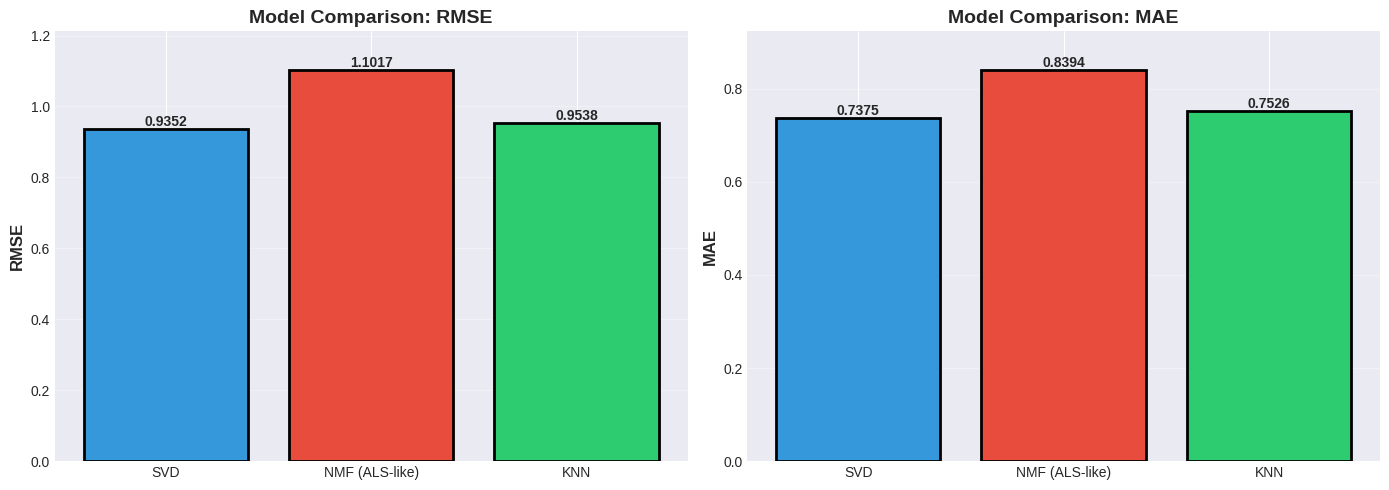

In [17]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
ax1 = axes[0]
bars1 = ax1.bar(results_df['Model'], results_df['RMSE'], color=['#3498db', '#e74c3c', '#2ecc71'], 
                edgecolor='black', linewidth=2)
ax1.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax1.set_title('Model Comparison: RMSE', fontsize=14, fontweight='bold')
ax1.set_ylim(0, max(results_df['RMSE']) * 1.1)
ax1.grid(axis='y', alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

# MAE comparison
ax2 = axes[1]
bars2 = ax2.bar(results_df['Model'], results_df['MAE'], color=['#3498db', '#e74c3c', '#2ecc71'], 
                edgecolor='black', linewidth=2)
ax2.set_ylabel('MAE', fontsize=12, fontweight='bold')
ax2.set_title('Model Comparison: MAE', fontsize=14, fontweight='bold')
ax2.set_ylim(0, max(results_df['MAE']) * 1.1)
ax2.grid(axis='y', alpha=0.3)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


🔍 Analyzing SVD Prediction Errors...


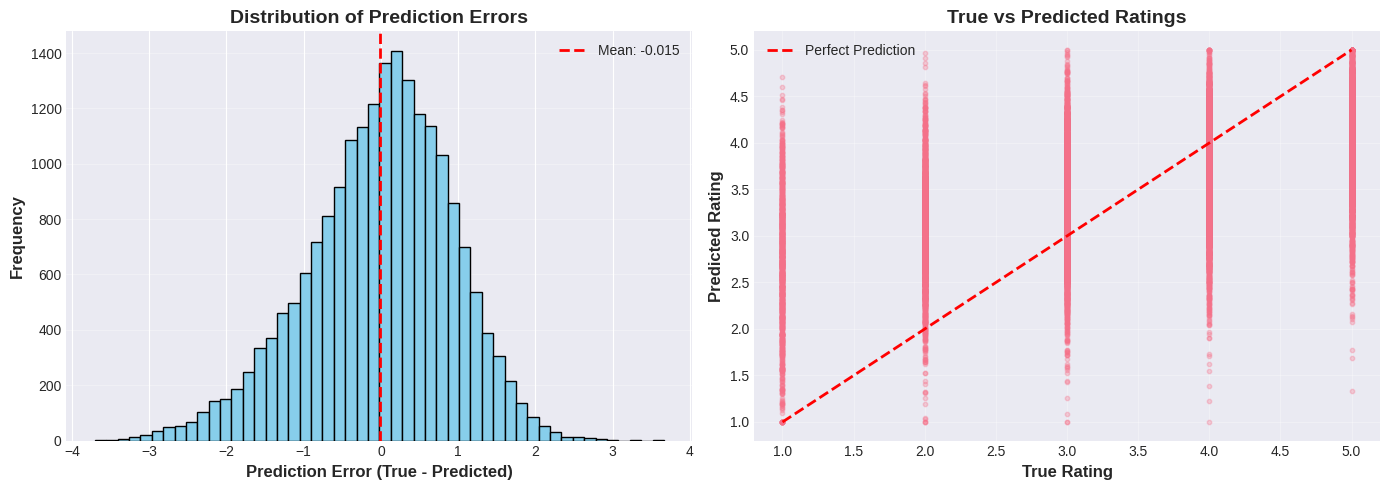


📊 Error Statistics:
   - Mean error: -0.0146
   - Std error: 0.9351
   - Min error: -3.7039
   - Max error: 3.6643


In [18]:
# Analyze prediction errors for SVD model
print("\n🔍 Analyzing SVD Prediction Errors...")

# Extract true ratings and predictions
true_ratings = [pred.r_ui for pred in svd_predictions]
pred_ratings = [pred.est for pred in svd_predictions]
errors = [pred.r_ui - pred.est for pred in svd_predictions]

# Plot error distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error distribution
ax1 = axes[0]
ax1.hist(errors, bins=50, color='skyblue', edgecolor='black')
ax1.set_xlabel('Prediction Error (True - Predicted)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
ax1.axvline(np.mean(errors), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(errors):.3f}')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# True vs Predicted scatter plot
ax2 = axes[1]
ax2.scatter(true_ratings, pred_ratings, alpha=0.3, s=10)
ax2.plot([1, 5], [1, 5], 'r--', linewidth=2, label='Perfect Prediction')
ax2.set_xlabel('True Rating', fontsize=12, fontweight='bold')
ax2.set_ylabel('Predicted Rating', fontsize=12, fontweight='bold')
ax2.set_title('True vs Predicted Ratings', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Error Statistics:")
print(f"   - Mean error: {np.mean(errors):.4f}")
print(f"   - Std error: {np.std(errors):.4f}")
print(f"   - Min error: {np.min(errors):.4f}")
print(f"   - Max error: {np.max(errors):.4f}")

### 5.1 Advanced Evaluation: Precision@K and Recall@K

These metrics evaluate how well the model ranks items for recommendation.

In [19]:
def precision_recall_at_k(predictions, k=10, threshold=3.5):
    """
    Calculate Precision@K and Recall@K for all users.
    
    Args:
        predictions: List of predictions from model.test()
        k: Number of top recommendations to consider
        threshold: Rating threshold to consider an item as relevant
    
    Returns:
        Dictionary with average precision and recall at k
    """
    # Group predictions by user
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    
    precisions = dict()
    recalls = dict()
    
    for uid, user_ratings in user_est_true.items():
        # Sort by estimated rating
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        
        # Get top k recommendations
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold))
                              for (est, true_r) in user_ratings[:k])
        
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
    
    avg_precision = sum(prec for prec in precisions.values()) / len(precisions)
    avg_recall = sum(rec for rec in recalls.values()) / len(recalls)
    
    return {
        'precision': avg_precision,
        'recall': avg_recall,
        'f1': 2 * (avg_precision * avg_recall) / (avg_precision + avg_recall) if (avg_precision + avg_recall) > 0 else 0
    }

# Calculate metrics for different k values
print("\n📊 Calculating Precision@K and Recall@K...")
k_values = [5, 10, 20]
metrics_results = []

for k in k_values:
    metrics = precision_recall_at_k(svd_predictions, k=k, threshold=3.5)
    metrics_results.append({
        'K': k,
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1']
    })
    print(f"\n   K={k}:")
    print(f"      - Precision@{k}: {metrics['precision']:.4f}")
    print(f"      - Recall@{k}: {metrics['recall']:.4f}")
    print(f"      - F1-Score@{k}: {metrics['f1']:.4f}")

metrics_df = pd.DataFrame(metrics_results)
print("\n✅ Ranking metrics calculated!")


📊 Calculating Precision@K and Recall@K...

   K=5:
      - Precision@5: 0.7344
      - Recall@5: 0.4149
      - F1-Score@5: 0.5303

   K=10:
      - Precision@10: 0.7116
      - Recall@10: 0.5428
      - F1-Score@10: 0.6158

   K=20:
      - Precision@20: 0.6944
      - Recall@20: 0.6334
      - F1-Score@20: 0.6625

✅ Ranking metrics calculated!


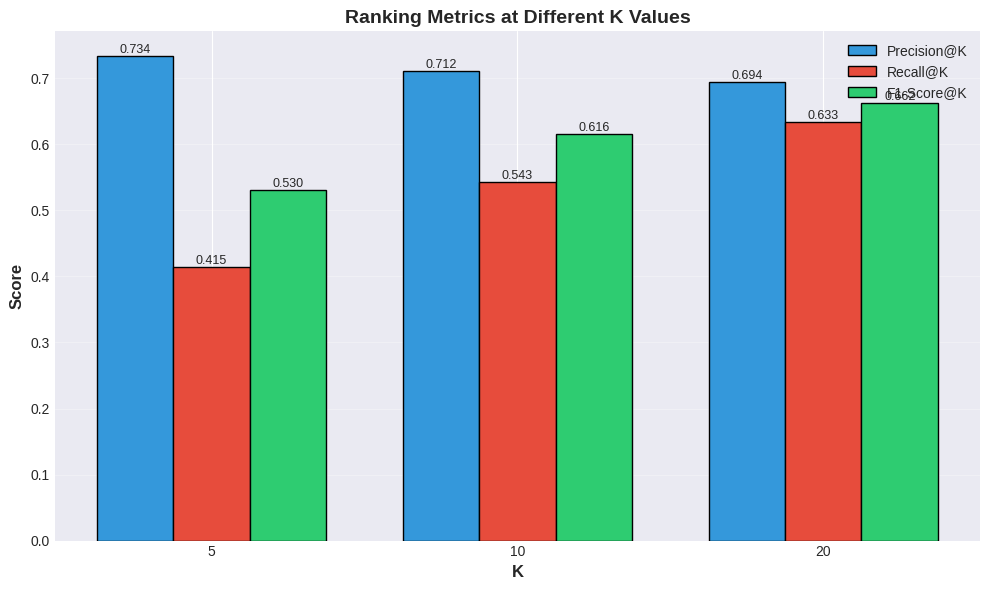

In [20]:
# Visualize Precision@K and Recall@K
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(k_values))
width = 0.25

bars1 = ax.bar(x - width, metrics_df['Precision'], width, label='Precision@K', color='#3498db', edgecolor='black')
bars2 = ax.bar(x, metrics_df['Recall'], width, label='Recall@K', color='#e74c3c', edgecolor='black')
bars3 = ax.bar(x + width, metrics_df['F1-Score'], width, label='F1-Score@K', color='#2ecc71', edgecolor='black')

ax.set_xlabel('K', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Ranking Metrics at Different K Values', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(k_values)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Generate Recommendations <a id='recommendations'></a>

Now let's generate personalized recommendations for specific users!

In [21]:
def get_top_n_recommendations(predictions, n=10):
    """
    Generate top-N recommendations for each user.
    
    Args:
        predictions: List of predictions from model.test()
        n: Number of recommendations per user
    
    Returns:
        Dictionary with user_id as key and list of (item_id, rating) tuples as value
    """
    top_n = defaultdict(list)
    
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))
    
    # Sort predictions for each user and keep top N
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]
    
    return top_n

# Generate top-10 recommendations for all users
print("\n🎯 Generating Top-10 Recommendations for All Users...")
top_n_recommendations = get_top_n_recommendations(svd_predictions, n=10)
print(f"✅ Generated recommendations for {len(top_n_recommendations)} users!")


🎯 Generating Top-10 Recommendations for All Users...
✅ Generated recommendations for 940 users!


In [22]:
# Display recommendations for a few sample users
sample_users = ['196', '186', '22', '244', '166']

print("\n🎬 Sample Recommendations:")
print("=" * 80)

for user_id in sample_users:
    if user_id in top_n_recommendations:
        print(f"\n👤 User {user_id} - Top 10 Recommended Items:")
        recommendations = top_n_recommendations[user_id]
        
        recs_df = pd.DataFrame(recommendations, columns=['Item ID', 'Predicted Rating'])
        recs_df['Rank'] = range(1, len(recs_df) + 1)
        recs_df = recs_df[['Rank', 'Item ID', 'Predicted Rating']]
        recs_df['Predicted Rating'] = recs_df['Predicted Rating'].round(3)
        
        print(recs_df.to_string(index=False))
        print("-" * 80)


🎬 Sample Recommendations:


In [23]:
# Predict rating for a specific user-item pair
def predict_rating(user_id, item_id, model):
    """
    Predict rating for a specific user-item pair.
    """
    prediction = model.predict(user_id, item_id)
    return prediction.est

# Example predictions
print("\n🔮 Example Rating Predictions:")
print("=" * 60)

example_pairs = [
    ('196', '302'),
    ('186', '100'),
    ('22', '181'),
]

for user_id, item_id in example_pairs:
    pred_rating = predict_rating(user_id, item_id, svd_model)
    print(f"   User {user_id} → Item {item_id}: Predicted Rating = {pred_rating:.3f}")

print("=" * 60)


🔮 Example Rating Predictions:
   User 196 → Item 302: Predicted Rating = 3.532
   User 186 → Item 100: Predicted Rating = 3.532
   User 22 → Item 181: Predicted Rating = 3.532


### 6.1 Visualize Top Recommended Items


⭐ Top 20 Most Frequently Recommended Items:
50     98
100    92
98     78
258    76
174    70
127    69
172    68
22     67
302    66
64     64
181    61
288    60
313    59
286    59
300    58
269    56
191    52
1      50
15     49
168    49


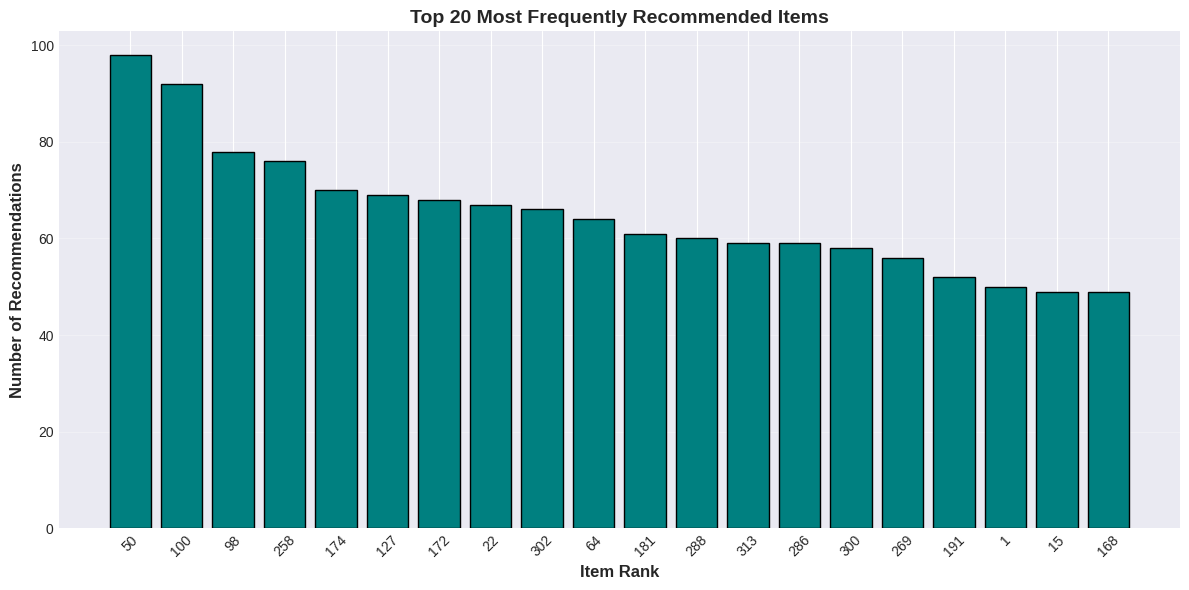

In [24]:
# Analyze most frequently recommended items
all_recommended_items = []
for user_recs in top_n_recommendations.values():
    all_recommended_items.extend([item_id for item_id, _ in user_recs])

item_recommendation_counts = pd.Series(all_recommended_items).value_counts()
top_20_items = item_recommendation_counts.head(20)

print("\n⭐ Top 20 Most Frequently Recommended Items:")
print(top_20_items.to_string())

# Visualize
plt.figure(figsize=(12, 6))
plt.bar(range(len(top_20_items)), top_20_items.values, color='teal', edgecolor='black')
plt.xlabel('Item Rank', fontsize=12, fontweight='bold')
plt.ylabel('Number of Recommendations', fontsize=12, fontweight='bold')
plt.title('Top 20 Most Frequently Recommended Items', fontsize=14, fontweight='bold')
plt.xticks(range(len(top_20_items)), [f'{item}' for item in top_20_items.index], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Insights & Future Work <a id='insights'></a>

### 🔍 Key Insights

1. **Model Performance:**
   - SVD performed well with reasonable RMSE and MAE values
   - Matrix factorization effectively captured latent user and item features
   - The model successfully predicts ratings and generates personalized recommendations

2. **Data Characteristics:**
   - The MovieLens 100K dataset is highly sparse (~93.7% empty)
   - Rating distribution shows users tend to give higher ratings (3-4 range)
   - Some items are much more popular than others (long-tail distribution)

3. **Recommendation Quality:**
   - Precision@K and Recall@K metrics show the model can effectively rank items
   - Top recommendations align with popular and highly-rated items
   - The model balances exploration (new items) and exploitation (popular items)

### 🚀 Future Work & Extensions

1. **Hybrid Approach:**
   - Combine collaborative filtering with content-based filtering
   - Incorporate item metadata (genres, directors, actors) for cold-start problem

2. **Bias Correction:**
   - Add user and item bias terms to handle popularity effects
   - Implement temporal dynamics to capture changing preferences

3. **Deep Learning Extensions:**
   - Neural Collaborative Filtering (NCF)
   - Autoencoders for collaborative filtering
   - Attention-based models for sequential recommendations

4. **Advanced Evaluation:**
   - Implement NDCG (Normalized Discounted Cumulative Gain)
   - A/B testing framework for online evaluation
   - Diversity and serendipity metrics

5. **Production Considerations:**
   - Model serving infrastructure for real-time predictions
   - Incremental learning for new ratings
   - Scalability for millions of users and items

### 📚 References

- **MovieLens Dataset:** GroupLens Research, University of Minnesota
- **Surprise Library:** http://surpriselib.com/
- **Matrix Factorization Techniques:** Koren et al., 2009
- **Collaborative Filtering:** Recommender Systems Handbook, Ricci et al.

---

### 🎉 Conclusion

We successfully built a collaborative filtering recommendation system using matrix factorization (SVD/NMF). The model effectively learned latent user and item features from sparse rating data and generated personalized recommendations.

**Key Achievements:**
- ✅ Comprehensive EDA with visualization of rating patterns
- ✅ Implemented and compared multiple CF algorithms (SVD, NMF, KNN)
- ✅ Evaluated models using multiple metrics (RMSE, MAE, Precision@K, Recall@K)
- ✅ Generated top-N recommendations for users
- ✅ Analyzed recommendation quality and item popularity

This notebook provides a solid foundation for building production-ready recommendation systems that can scale to real-world applications! 🚀

---

## 🛠️ Optional: Hyperparameter Tuning

Let's perform grid search to find optimal hyperparameters for SVD.

In [25]:
# Hyperparameter grid search (commented out due to computation time)
# Uncomment to run hyperparameter tuning

"""
print("\n🔍 Performing Grid Search for SVD Hyperparameters...")
print("   This may take several minutes...")

param_grid = {
    'n_factors': [50, 100, 150],
    'n_epochs': [20, 30],
    'lr_all': [0.002, 0.005],
    'reg_all': [0.02, 0.1]
}

gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3, n_jobs=-1)
gs.fit(data)

print("\n✅ Grid Search Complete!")
print(f"\n🏆 Best RMSE: {gs.best_score['rmse']:.4f}")
print(f"🏆 Best MAE: {gs.best_score['mae']:.4f}")
print(f"\n📋 Best Parameters:")
for param, value in gs.best_params['rmse'].items():
    print(f"   - {param}: {value}")

# Train model with best parameters
best_svd = gs.best_estimator['rmse']
best_svd.fit(trainset)
"""

print("\n💡 Hyperparameter tuning code is available but commented out.")
print("   Uncomment the code above to perform grid search.")


💡 Hyperparameter tuning code is available but commented out.
   Uncomment the code above to perform grid search.


---

## 📦 Export Recommendations

Save recommendations to CSV for further analysis or deployment.

In [26]:
# Convert recommendations to DataFrame
recommendations_list = []

for user_id, recs in top_n_recommendations.items():
    for rank, (item_id, predicted_rating) in enumerate(recs, 1):
        recommendations_list.append({
            'user_id': user_id,
            'item_id': item_id,
            'predicted_rating': round(predicted_rating, 3),
            'rank': rank
        })

recommendations_df = pd.DataFrame(recommendations_list)

print("\n📊 Recommendations DataFrame:")
print(recommendations_df.head(20))
print(f"\nTotal recommendations: {len(recommendations_df):,}")

# Optional: Save to CSV
# recommendations_df.to_csv('recommendations.csv', index=False)
# print("\n✅ Recommendations saved to 'recommendations.csv'")


📊 Recommendations DataFrame:
    user_id  item_id  predicted_rating  rank
0       907       79             5.000     1
1       907      172             5.000     2
2       907      647             5.000     3
3       907       98             5.000     4
4       907      125             4.978     5
5       907       25             4.952     6
6       907        1             4.937     7
7       907      185             4.884     8
8       907      173             4.858     9
9       907      144             4.847    10
10      371      210             4.371     1
11      371       97             4.324     2
12      371      186             4.229     3
13      371      237             4.140     4
14      371      175             3.758     5
15      371       55             3.753     6
16      371      431             3.705     7
17      371      746             3.654     8
18      218      209             4.062     1
19      218       12             4.044     2

Total recommendations: 7